## Copying Model


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import powerlaw
import random
from collections import Counter
import pandas as pd

random.seed(42)
np.random.seed(42)

def generate_copying_model(N, ell, alpha):
    G = nx.DiGraph()
    G.add_node(0)

    for i in range(1, ell + 2):
        G.add_node(i)
        for _ in range(ell):
            target = random.choice(list(G.nodes)[:i])
            if target != i:
                G.add_edge(i, target)

    for t in range(len(G), N):
        G.add_node(t)
        targets = set()   # no duplicate edges
        attempts = 0
        while len(targets) < ell and attempts < 10 * ell:
            attempts += 1
            if random.random() < alpha:
                candidate = random.choice(list(G.nodes)[:-1])
            else:
                parent = random.choice(list(G.nodes)[:-1])
                out_edges = list(G.out_edges(parent))
                if out_edges:
                    candidate = random.choice(out_edges)[1]
                else:
                    candidate = random.choice(list(G.nodes)[:-1])
            if candidate != t:
                targets.add(candidate)
        for target in targets:
            G.add_edge(t, target)
    return G

def get_in_degrees(G):
    return [d for _, d in G.in_degree()]

def plot_loglog_with_fits(degrees, gamma_hat, k_min, alpha, ell, upper_quantile=0.9):
    degree_counts = Counter(degrees)
    deg = np.array(sorted(degree_counts.keys()))
    probs = np.array([degree_counts[k] for k in deg]) / sum(degree_counts.values())

    mask = (deg >= k_min) & (deg <= np.quantile(deg, upper_quantile)) & (probs > 0)
    x = np.log(deg[mask])
    y = np.log(probs[mask])
    gamma_theory = 1 + 1 / (ell * (1- alpha))

    plt.figure(figsize=(8, 6))
    plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')

    if len(x) >= 2:
        b_mle = np.mean(y + gamma_hat * x)
        plt.plot(x, -gamma_hat * x + b_mle, 'r-', label=f'MLE fit ($\\hat{{\\gamma}}$={gamma_hat:.2f})')
        b_theory = np.mean(y + gamma_theory * x)
        plt.plot(x, -gamma_theory * x + b_theory, 'g--', label=f'Theory ($\\gamma$={gamma_theory:.2f})')
    else:
        b_mle = b_theory = np.nan

    plt.xlabel("log Degree")
    plt.ylabel("log P(k)")
    plt.title("Log-Log In-degree Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return b_mle, b_theory

def analyze_copying_model(N, ell, alpha):
    print(f"\nSimulating Copying Model with N={N}, ell={ell}, alpha={alpha}...")
    G = generate_copying_model(N, ell, alpha)
    degrees = get_in_degrees(G)

    fit = powerlaw.Fit(degrees, discrete=True)
    gamma_hat = fit.alpha
    k_min = fit.xmin
    ks_dist = fit.D
    R, p_val = fit.distribution_compare('power_law', 'lognormal')
    max_degree = np.max(degrees)
    avg_degree = np.mean(degrees)

    b_mle, b_theory = plot_loglog_with_fits(degrees, gamma_hat, k_min, alpha, ell, upper_quantile=0.9)

    fig = fit.plot_pdf(color='b', label='Empirical PDF')
    fit.power_law.plot_pdf(color='r', linestyle='--', label='Power law fit', ax=fig)
    plt.title("PDF with Power Law Fit")
    plt.xlabel("Degree")
    plt.ylabel("P(k)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    for dist in ['lognormal', 'exponential']:
        R_other, p_other = fit.distribution_compare('power_law', dist)
        print(f"Compare power_law vs {dist}: R = {R_other:.3f}, p = {p_other:.4f}")

    print(f"MLE estimated γ̂ = {gamma_hat:.3f}")
    print(f"Maximum degree = {max_degree}")
    print(f"Average degree = {avg_degree:.3f}")
    print(f"k_min = {k_min}")
    print(f"KS distance = {ks_dist:.4f}")
    print(f"p-value (power-law vs lognormal) = {p_val:.4f}")
    print(f"Intercept (MLE fit) = {b_mle:.3f}")
    print(f"Intercept (Theory gamma=3) = {b_theory:.3f}")

    return gamma_hat, max_degree, avg_degree, ks_dist, p_val, b_mle, b_theory



Simulating Copying Model with N=1000, ell=1, alpha=0.1...
Calculating best minimal value for power law fit


Values less than or equal to 0 in data. Throwing out 0 or negative values
c:\Users\75585\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw.py:1570: RuntimeWarning: divide by zero encountered in divide
  return likelihoods/norm
c:\Users\75585\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw.py:1570: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
c:\Users\75585\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw.py:1570: RuntimeWarning: overflow encountered in divide
  return likelihoods/norm
C:\Users\75585\AppData\Local\Temp\ipykernel_26824\2219896774.py:58: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


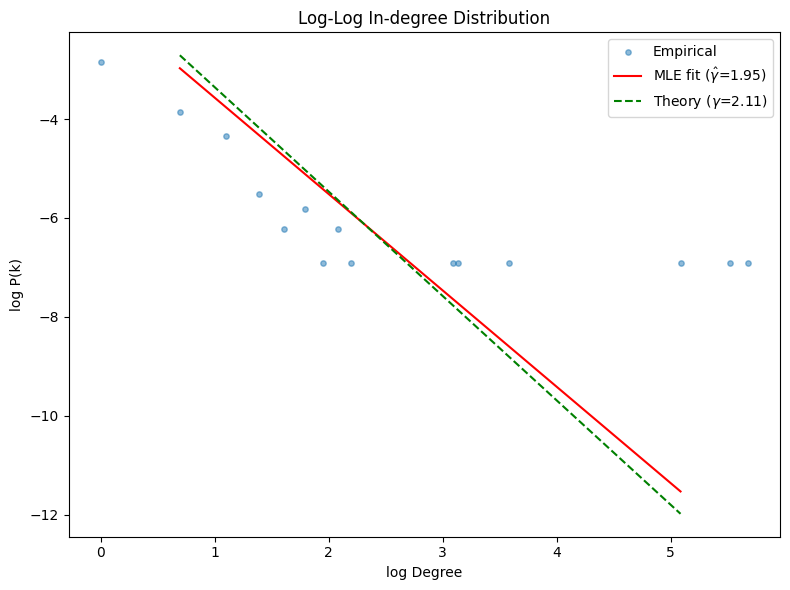

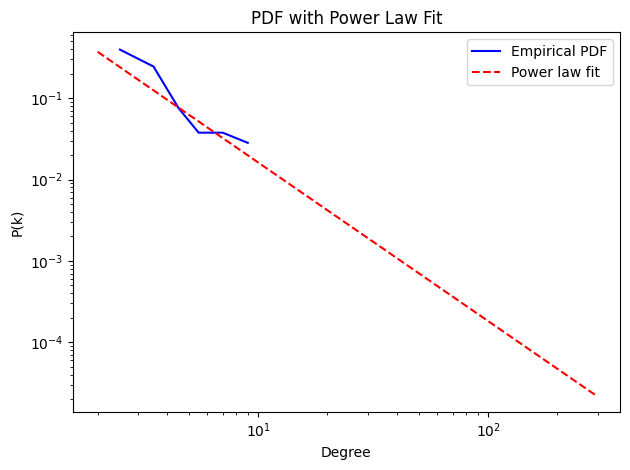

Compare power_law vs lognormal: R = -5.852, p = 0.2884
Compare power_law vs exponential: R = 69.225, p = 0.0000
MLE estimated γ̂ = 1.948
Maximum degree = 292
Average degree = 0.999
k_min = 2.0
KS distance = 0.1003
p-value (power-law vs lognormal) = 0.2884
Intercept (MLE fit) = -1.620
Intercept (Theory gamma=3) = -1.245


(1.948433696715878,
 292,
 0.999,
 0.10034958515589665,
 0.2884277494909312,
 -1.6201492876933006,
 -1.244642646640222)

In [3]:
analyze_copying_model(1000,1,0.1)


Simulating Copying Model with N=10000, ell=1, alpha=0.1...


Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit


C:\Users\75585\AppData\Local\Temp\ipykernel_26824\2219896774.py:58: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


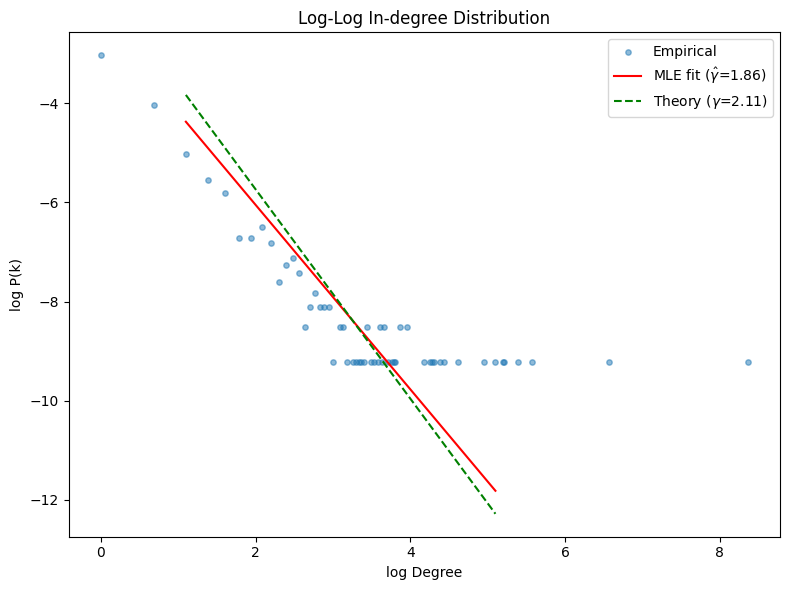

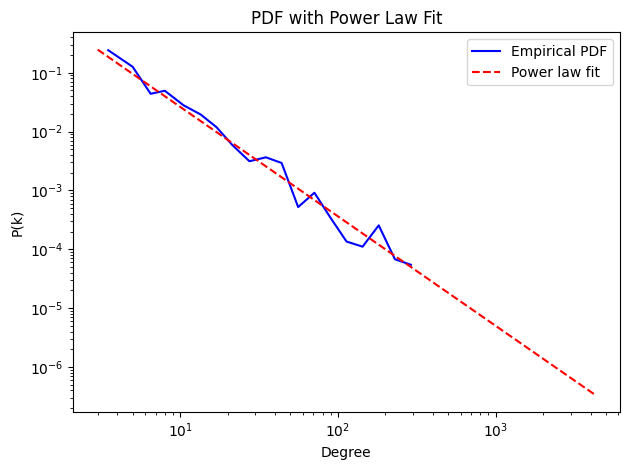

Compare power_law vs lognormal: R = -0.406, p = 0.6513
Compare power_law vs exponential: R = 332.040, p = 0.0092
MLE estimated γ̂ = 1.860
Maximum degree = 4274
Average degree = 1.000
k_min = 3.0
KS distance = 0.0253
p-value (power-law vs lognormal) = 0.6513
Intercept (MLE fit) = -2.329
Intercept (Theory gamma=3) = -1.513


(1.8600674194031606,
 4274,
 0.9999,
 0.025324963520582,
 0.651288081584495,
 -2.329198023373852,
 -1.513188851299648)

In [2]:
analyze_copying_model(10000,1,0.1)


Simulating Copying Model with N=100000, ell=1, alpha=0.1...


Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit


C:\Users\75585\AppData\Local\Temp\ipykernel_26824\2219896774.py:58: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


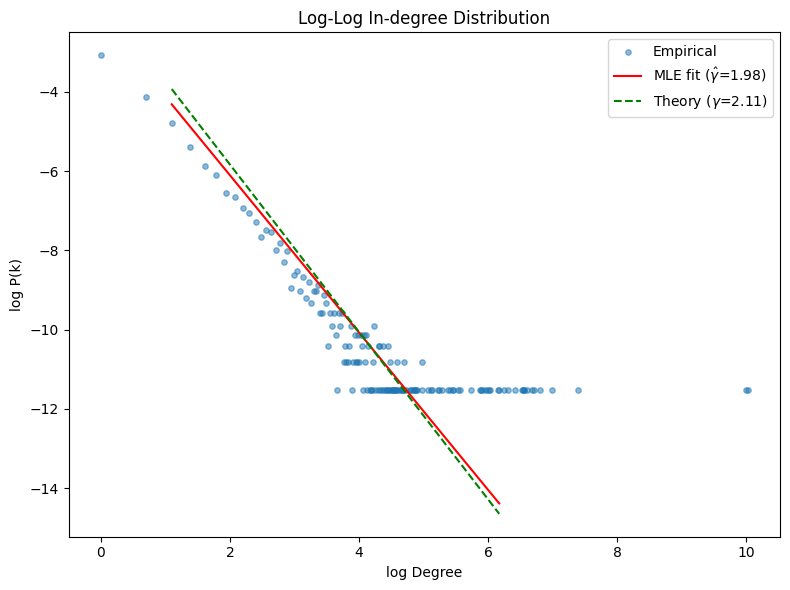

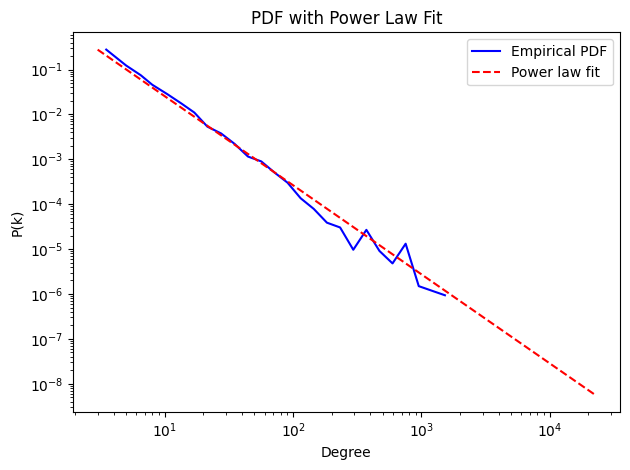

Compare power_law vs lognormal: R = -2.383, p = 0.3481
Compare power_law vs exponential: R = 3384.968, p = 0.0007
MLE estimated γ̂ = 1.984
Maximum degree = 22572
Average degree = 1.000
k_min = 3.0
KS distance = 0.0128
p-value (power-law vs lognormal) = 0.3481
Intercept (MLE fit) = -2.136
Intercept (Theory gamma=3) = -1.611


(1.983648421771083,
 22572,
 0.99999,
 0.012797467625856651,
 0.3481365918099113,
 -2.1360902330105658,
 -1.6107303092967489)

In [4]:
analyze_copying_model(100000,1,0.1)

In [ ]:
analyze_copying_model(1000,1,0.5)


Simulating Copying Model with N=10000, ell=1, alpha=0.5...


Values less than or equal to 0 in data. Throwing out 0 or negative values
C:\Users\75585\AppData\Local\Temp\ipykernel_22208\828236517.py:57: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


Calculating best minimal value for power law fit


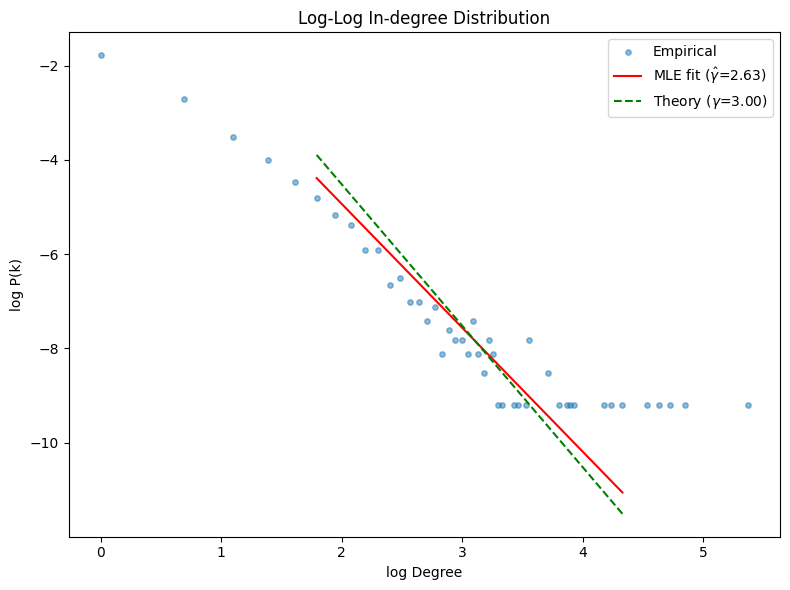

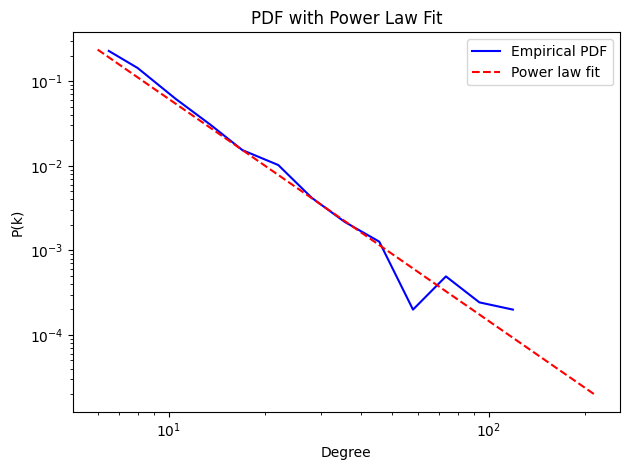

Compare power_law vs lognormal: R = -0.076, p = 0.8187
Compare power_law vs exponential: R = 81.243, p = 0.0007
MLE estimated γ̂ = 2.628
Maximum degree = 215
Average degree = 1.000
k_min = 6.0
KS distance = 0.0163
p-value (power-law vs lognormal) = 0.8187
Intercept (MLE fit) = 0.323
Intercept (Theory γ=3) = 1.483


(2.627658456848247,
 215,
 0.9999,
 0.016277207183217124,
 0.818696888287139,
 0.3225297628808364,
 1.4825118797962342)

In [10]:
analyze_copying_model(10000,1,0.5)


Simulating Copying Model with N=100000, ell=1, alpha=0.5...


Values less than or equal to 0 in data. Throwing out 0 or negative values


Calculating best minimal value for power law fit


C:\Users\75585\AppData\Local\Temp\ipykernel_10624\2219896774.py:58: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


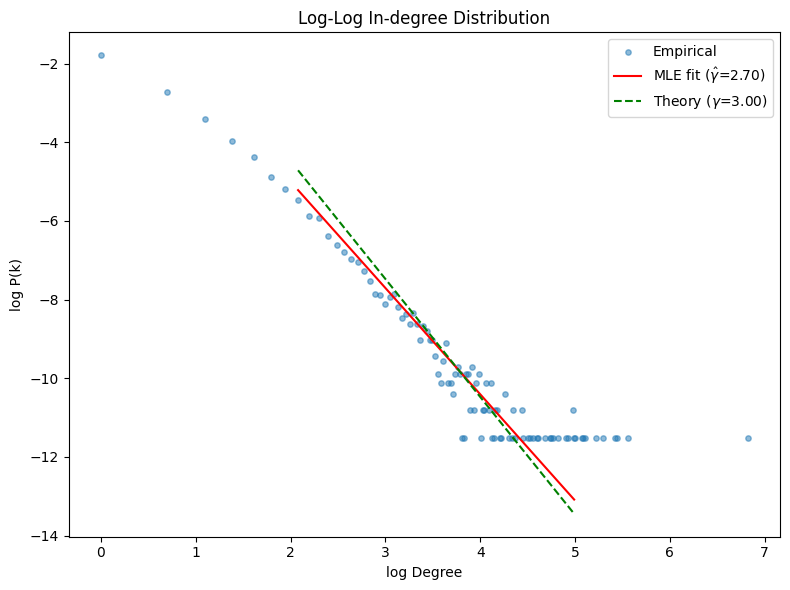

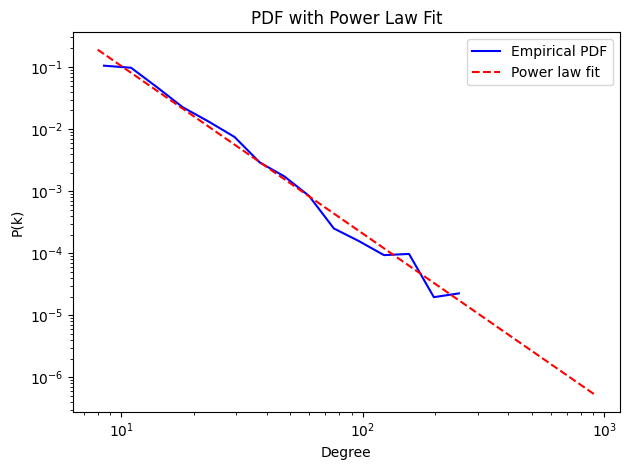

Compare power_law vs lognormal: R = -2.720, p = 0.2273
Compare power_law vs exponential: R = 416.818, p = 0.0000
MLE estimated γ̂ = 2.703
Maximum degree = 916
Average degree = 1.000
k_min = 8.0
KS distance = 0.0146
p-value (power-law vs lognormal) = 0.2273
Intercept (MLE fit) = 0.401
Intercept (Theory gamma=3) = 1.523


(2.702614525234284,
 916,
 0.99999,
 0.01458234941053288,
 0.22728246327608292,
 0.4014603034884728,
 1.5233609896480078)

In [26]:
analyze_copying_model(100000,1,0.5)

In [ ]:
analyze_copying_model(1000,1,0.9)


Simulating Copying Model with N=10000, ell=1, alpha=0.9...


Values less than or equal to 0 in data. Throwing out 0 or negative values
C:\Users\75585\AppData\Local\Temp\ipykernel_22208\828236517.py:57: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


Calculating best minimal value for power law fit


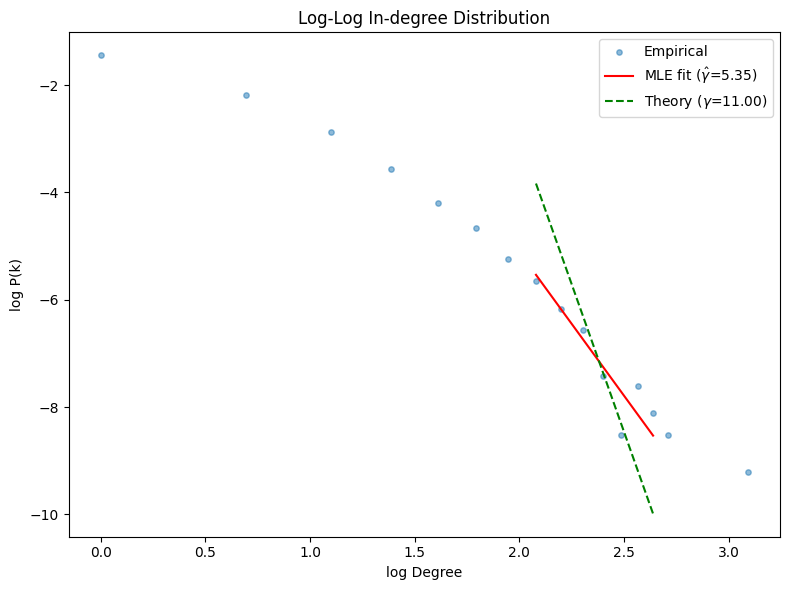

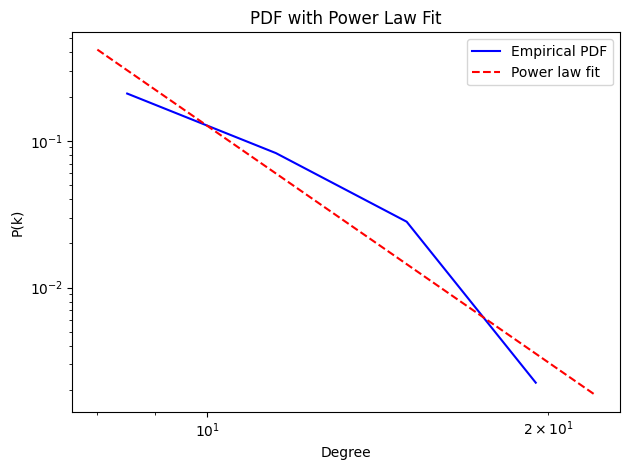

Compare power_law vs lognormal: R = -0.656, p = 0.4930
Compare power_law vs exponential: R = -0.404, p = 0.8107
MLE estimated γ̂ = 5.355
Maximum degree = 22
Average degree = 1.000
k_min = 8.0
KS distance = 0.0248
p-value (power-law vs lognormal) = 0.4930
Intercept (MLE fit) = 5.600
Intercept (Theory γ=3) = 19.041


(5.354582577170778,
 22,
 0.9999,
 0.024755981609867916,
 0.49300164510370303,
 5.599899375300374,
 19.040880016327286)

In [11]:
analyze_copying_model(10000,1,0.9)


Simulating Copying Model with N=100000, ell=1, alpha=0.9...


Values less than or equal to 0 in data. Throwing out 0 or negative values
C:\Users\75585\AppData\Local\Temp\ipykernel_10624\2219896774.py:58: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(deg), np.log(probs), s=15, alpha=0.5, label='Empirical')


Calculating best minimal value for power law fit


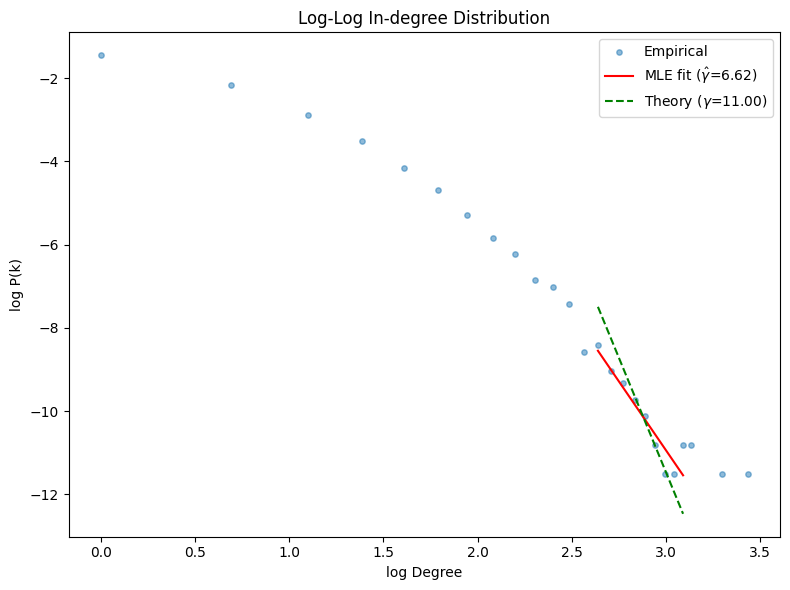

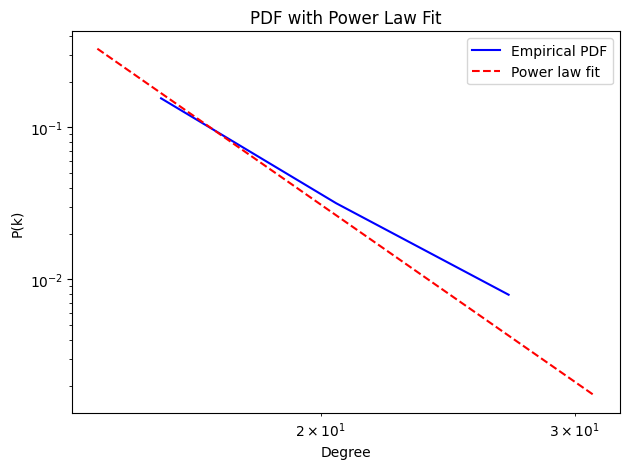

Compare power_law vs lognormal: R = -0.010, p = 0.9323
Compare power_law vs exponential: R = 0.787, p = 0.4939
MLE estimated γ̂ = 6.619
Maximum degree = 31
Average degree = 1.000
k_min = 14.0
KS distance = 0.0217
p-value (power-law vs lognormal) = 0.9323
Intercept (MLE fit) = 8.919
Intercept (Theory gamma=3) = 21.537


(6.618724508542486,
 31,
 0.99999,
 0.02167722399969707,
 0.9322852904191019,
 8.919114338142629,
 21.536709463672015)

In [24]:
analyze_copying_model(100000,1,0.9)

In [ ]:
def fit_powerlaw(degrees):
    """
    Fit a power-law to the degree distribution.
    Return: gamma, KS, R_log, p_log, R_exp, p_exp
    """
    degrees = [d for d in degrees if d > 0]  
    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    ks = fit.power_law.KS()
    R_log, p_log = fit.distribution_compare('power_law', 'lognormal')
    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
    return gamma, ks, R_log, p_log, R_exp, p_exp

def plot_gamma_comparison(alpha_list, gamma_sim_list, gamma_theory_list):
    plt.figure(figsize=(8, 5))
    plt.plot(alpha_list, gamma_theory_list, marker='o', label="Theoretical γ")
    plt.plot(alpha_list, gamma_sim_list, marker='x', label="Simulated γ")
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"Power-law exponent $\gamma$")
    plt.title("Theoretical vs Simulated $\gamma$ in Copying Model")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def run_copying_model_analysis(alpha_list, N, ell, n_trials, generate_copying_model, get_in_degrees):
    result_list = []

    for alpha in alpha_list:
        gammas, ks_list, R_logs, p_logs, R_exps, p_exps = [], [], [], [], [], []

        for _ in range(n_trials):
            G = generate_copying_model(N, ell, alpha)
            degrees = get_in_degrees(G)
            gamma, ks, R_log, p_log, R_exp, p_exp = fit_powerlaw(degrees)
            gammas.append(gamma)
            ks_list.append(ks)
            R_logs.append(R_log)
            p_logs.append(p_log)
            R_exps.append(R_exp)
            p_exps.append(p_exp)

        avg_gamma = np.mean(gammas)
        avg_ks = np.mean(ks_list)
        avg_R_log = np.mean(R_logs)
        avg_p_log = np.mean(p_logs)
        avg_R_exp = np.mean(R_exps)
        avg_p_exp = np.mean(p_exps)
        gamma_theory = 1 + 1 / (ell * (1 - alpha)) if alpha > 0 else 1

        print(f"α={alpha:.2f} → γ̂={avg_gamma:.3f}, γ_theory={gamma_theory:.3f}, KS={avg_ks:.4f}, "
      f"R_log={avg_R_log:.3f}, p_log={avg_p_log:.3f}, "
      f"R_exp={avg_R_exp:.3f}, p_exp={avg_p_exp:.3f}")


        result_list.append({
            "alpha": alpha,
            "gamma_sim": avg_gamma,
            "gamma_theory": gamma_theory,
            "ks": avg_ks,
            "R_log": avg_R_log,
            "p_log": avg_p_log,
            "R_exp": avg_R_exp,
            "p_exp": avg_p_exp
        })

    df = pd.DataFrame(result_list)

    plot_gamma_comparison(df["alpha"], df["gamma_sim"], df["gamma_theory"])

    return df


c:\Users\75585\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw.py:1570: RuntimeWarning: divide by zero encountered in divide
  return likelihoods/norm
c:\Users\75585\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw.py:1570: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
c:\Users\75585\AppData\Local\Programs\Python\Python311\Lib\site-packages\powerlaw.py:1570: RuntimeWarning: overflow encountered in divide
  return likelihoods/norm


α=0.10 → γ̂=1.950, γ_theory=2.111, KS=0.0317, R_log=-3.669, p_log=0.558, R_exp=431.072, p_exp=0.001
α=0.20 → γ̂=2.028, γ_theory=2.250, KS=0.0240, R_log=-1.081, p_log=0.614, R_exp=500.889, p_exp=0.004
α=0.30 → γ̂=2.184, γ_theory=2.429, KS=0.0202, R_log=-1.353, p_log=0.550, R_exp=293.110, p_exp=0.002
α=0.40 → γ̂=2.325, γ_theory=2.667, KS=0.0201, R_log=-1.775, p_log=0.377, R_exp=221.681, p_exp=0.004
α=0.50 → γ̂=2.517, γ_theory=3.000, KS=0.0207, R_log=-2.550, p_log=0.360, R_exp=120.621, p_exp=0.001
α=0.60 → γ̂=2.827, γ_theory=3.500, KS=0.0217, R_log=-2.975, p_log=0.422, R_exp=61.055, p_exp=0.012
α=0.70 → γ̂=3.117, γ_theory=4.333, KS=0.0239, R_log=-3.713, p_log=0.270, R_exp=28.742, p_exp=0.085
α=0.80 → γ̂=3.481, γ_theory=6.000, KS=0.0223, R_log=-4.406, p_log=0.155, R_exp=6.892, p_exp=0.454
α=0.90 → γ̂=4.756, γ_theory=11.000, KS=0.0258, R_log=-2.342, p_log=0.374, R_exp=-0.830, p_exp=0.578


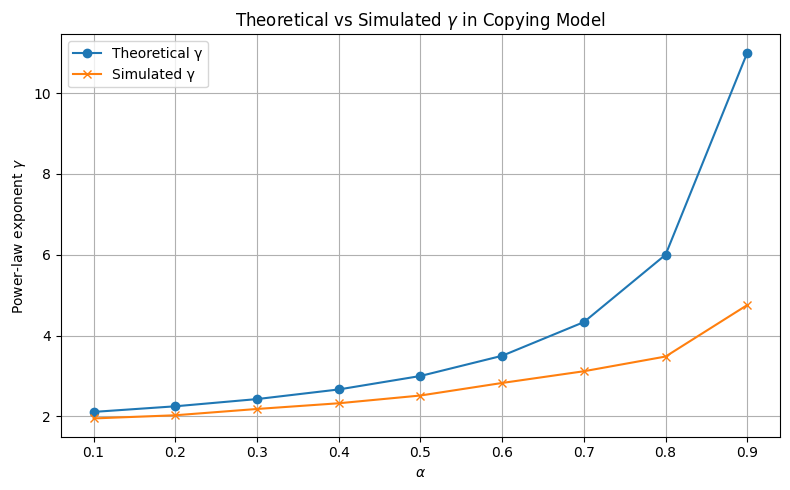

,alpha,gamma_sim,gamma_theory,ks,R_log,p_log,R_exp,p_exp
0,0.1,1.949769,2.111111,0.031698,-3.668997,0.557619,431.072158,0.001111
1,0.2,2.028085,2.250000,0.023972,-1.081367,0.613866,500.888512,0.004108
2,0.3,2.183841,2.428571,0.020189,-1.352510,0.550412,293.110156,0.001609
3,0.4,2.325120,2.666667,0.020066,-1.774949,0.376732,221.681074,0.003540
4,0.5,2.516770,3.000000,0.020748,-2.550131,0.360448,120.620997,0.001007
5,0.6,2.827474,3.500000,0.021698,-2.975443,0.422115,61.054545,0.012008
6,0.7,3.117270,4.333333,0.023919,-3.712662,0.269862,28.742169,0.084895
7,0.8,3.481363,6.000000,0.022317,-4.405676,0.155097,6.892133,0.454035
8,0.9,4.756032,11.000000,0.025806,-2.341767,0.374472,-0.829821,0.577942


In [ ]:
alpha_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
N=10000
ell=1
n_trials=10

run_copying_model_analysis(alpha_list, N, ell, n_trials, generate_copying_model, get_in_degrees)